In [1]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout,
    BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
x_train = np.load("x_train.npy")
y_train = np.load("y_train.npy")

x_validation = np.load("x_validation.npy")
y_validation = np.load("y_validation.npy")

x_test = np.load("x_test.npy")
y_test = np.load("y_test.npy")

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)

print("\nValidation images:", x_validation.shape)
print("Validation labels:", y_validation.shape)

print("\nTest images:", x_test.shape)
print("Test labels:", y_test.shape)

Training images: (36400, 32, 32, 3)
Training labels: (36400, 24)

Validation images: (9100, 32, 32, 3)
Validation labels: (9100, 24)

Test images: (9100, 32, 32, 3)
Test labels: (9100, 24)


In [3]:
final_classes = [
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "horse",
    "truck",
    "cattle",
    "fox",
    "baby",
    "boy",
    "girl",
    "man",
    "woman",
    "rabbit",
    "squirrel",
    "bicycle",
    "bus",
    "motorcycle",
    "pickup_truck",
    "train",
    "lawn_mower",
    "tractor",
    "trees"
]
num_classes = len(final_classes)

print("\nNumber of classes:", num_classes)


Number of classes: 24


In [4]:
assert y_train.shape[1] == 24
assert y_validation.shape[1] == 24
assert y_test.shape[1] == 24

print("Minimum pixel value in training set:", x_train.min())
print("Maximum pixel value in training set:", x_train.max())

Minimum pixel value in training set: 0.0
Maximum pixel value in training set: 1.0


In [5]:
baseline_accuracy = 0.6147
improved_accuracy = 0.7208

# Calculate class weight

In [6]:
y_train_integer = np.argmax(y_train, axis=1)

class_weight_array = compute_class_weight(
    class_weight='balanced',    
    classes = np.arange(num_classes),
    y = y_train_integer
)

class_weights = {class_index: weight for class_index, weight in enumerate(class_weight_array)}

print("Class Weights:\n")
for class_index, weight in class_weights.items():
    print(f"{class_index:2d} -"
    f" ({final_classes[class_index]:15s}):" 
    f" {weight:.4f}"
    )

Class Weights:

 0 - (automobile     ): 0.3792
 1 - (bird           ): 0.3792
 2 - (cat            ): 0.3792
 3 - (deer           ): 0.3792
 4 - (dog            ): 0.3792
 5 - (horse          ): 0.3792
 6 - (truck          ): 0.3792
 7 - (cattle         ): 3.7917
 8 - (fox            ): 3.7917
 9 - (baby           ): 3.7917
10 - (boy            ): 3.7917
11 - (girl           ): 3.7917
12 - (man            ): 3.7917
13 - (woman          ): 3.7917
14 - (rabbit         ): 3.7917
15 - (squirrel       ): 3.7917
16 - (bicycle        ): 0.7583
17 - (bus            ): 3.7917
18 - (motorcycle     ): 3.7917
19 - (pickup_truck   ): 3.7917
20 - (train          ): 3.7917
21 - (lawn_mower     ): 3.7917
22 - (tractor        ): 3.7917
23 - (trees          ): 3.7917


# Creating data augmentation

In [10]:
data_augmentation = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
)

print("Data augmentation pipeline created.")


Data augmentation pipeline created.


# Building data augmentation model

In [11]:
augmented_model = Sequential([
    Conv2D(32, 
    (3, 3), 
    activation='relu', 
    input_shape=(32, 32, 3)),
    BatchNormalization(),
    
    Conv2D(32, (3, 3), activation='relu'),
    BatchNormalization(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Conv2D(64, (3, 3), activation='relu'),
    BatchNormalization(),

    MaxPooling2D((2, 2)),
    Dropout(0.25),

    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

c:\Users\eljes\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [12]:
augmented_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

augmented_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 24)             │         6,168 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 626,424 (2.39 MB)

 Trainable params: 625,656 (2.39 MB)

 Non-trainable params: 768 (3.00 KB)

In [13]:
early_stopping_augmented = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Training Augmented Model

In [15]:
history_augmented = augmented_model.fit(
    data_augmentation.flow(
    x_train, 
    y_train, 
    batch_size=64,
    shuffle=True
    ),

    epochs= 40,
    validation_data=(x_validation, y_validation),
    class_weight=class_weights,
    callbacks=[early_stopping_augmented],
    verbose=1
)

Epoch 1/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.1491 - loss: 3.1189 - val_accuracy: 0.1708 - val_loss: 2.5569
Epoch 2/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 24s 42ms/step - accuracy: 0.2104 - loss: 2.4917 - val_accuracy: 0.2552 - val_loss: 2.2713
Epoch 3/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.2567 - loss: 2.2672 - val_accuracy: 0.1187 - val_loss: 3.5503
Epoch 4/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 26s 46ms/step - accuracy: 0.2779 - loss: 2.1873 - val_accuracy: 0.2980 - val_loss: 2.2863
Epoch 5/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.3045 - loss: 2.1101 - val_accuracy: 0.2903 - val_loss: 2.2641
Epoch 6/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 25s 45ms/step - accuracy: 0.3221 - loss: 2.0363 - val_accuracy: 0.2703 - val_loss: 2.3404
Epoch 7/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.3334 - loss: 1.9915 - val_accuracy: 0.2971 - val_loss: 2.1477
Epoch 8/40
569/569 ━━━━━━━━━━━━━━━━━━━━ 26s 45ms/step - accuracy: 0.3450 - loss: 1.9387 - 

# Evaluating the test set

In [17]:
augmented_test_loss, augmented_test_accuracy = augmented_model.evaluate(
 x_test,
 y_test, 
 verbose=1)

print(f"\nAugmented Model Test Loss: {augmented_test_loss:.4f}")
print(f"Augmented Model Test Accuracy: {augmented_test_accuracy:.4f}")
print(f"Augmented Model Test Accuracy:{augmented_test_accuracy * 100:.2f}%")

285/285 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5399 - loss: 1.4342

Augmented Model Test Loss: 1.4342
Augmented Model Test Accuracy: 0.5399
Augmented Model Test Accuracy:53.99%


# Plotting Accuracy

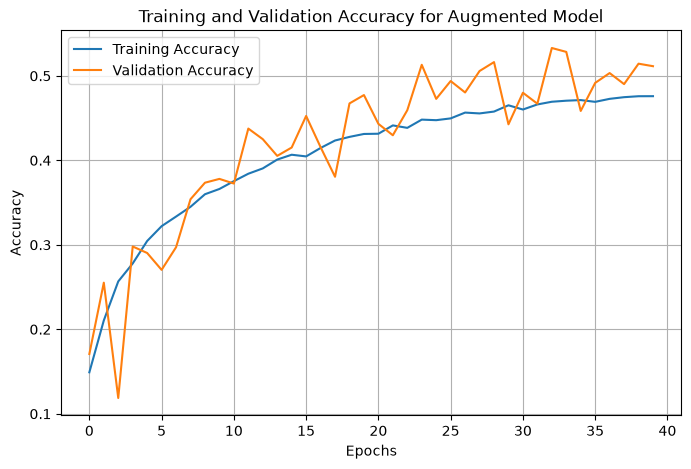

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(history_augmented.history['accuracy'], label='Training Accuracy')

plt.plot(history_augmented.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy for Augmented Model')

plt.legend()
plt.grid(True)
plt.show()

# Plotting Loss

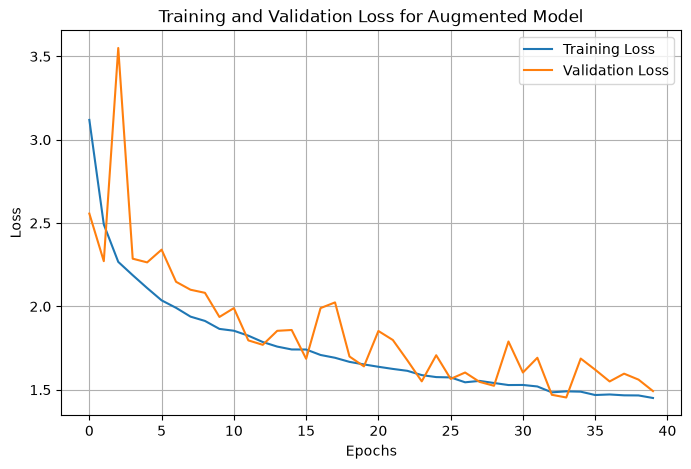

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    history_augmented.history['loss'],
    label='Training Loss'
)

plt.plot(
    history_augmented.history['val_loss'],
    label='Validation Loss'
)

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss for Augmented Model')
plt.legend()
plt.grid(True)
plt.show()